<a href="https://colab.research.google.com/github/ArmandoBarrios/unidad-4/blob/main/unidad_4_practica3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Unidad 4 practica 3
#Alumno:Armando Barrios

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

#Cargar el dataset
from google.colab import drive
drive.mount('/content/drive')
#ID del archivo
#https://drive.google.com/file/d/1V5ANwclpm0o4aHH_HvFeD0P0db0rqZOO/view?usp=sharing

file_id = "1V5ANwclpm0o4aHH_HvFeD0P0db0rqZOO"

url = f"https://drive.google.com/uc?id={file_id}"

#cargar datos
prestamos=pd.read_csv(url)
prestamos.head()

Mounted at /content/drive


,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,application_type,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens,hardship_flag,disbursement_method,debt_settlement_flag,debt_settlement_flag_date
0,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
1,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
2,3000,3000,3000.0,36 months,18.64,109.43,E,E1,MKC Accounting,9 years,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
3,5600,5600,5600.0,60 months,21.28,152.39,F,F2,NaN,4 years,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
4,5375,5375,5350.0,60 months,12.69,121.45,B,B5,Starbucks,< 1 year,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN


In [2]:
model_columns = ['funded_amnt', "int_rate", "grade", 'purpose',
'addr_state',
'home_ownership', 'annual_inc', 'dti', 'revol_util',
'pub_rec_bankruptcies']
X = prestamos[model_columns]
X.head()


,funded_amnt,int_rate,grade,purpose,addr_state,home_ownership,annual_inc,dti,revol_util,pub_rec_bankruptcies
0,2400,15.96,C,small_business,IL,RENT,12252.0,8.72,98.5,0.0
1,10000,13.49,C,other,CA,RENT,49200.0,20.00,21.0,0.0
2,3000,18.64,E,car,CA,RENT,48000.0,5.35,87.5,0.0
3,5600,21.28,F,small_business,CA,OWN,40000.0,5.55,32.6,0.0
4,5375,12.69,B,other,TX,RENT,15000.0,18.08,36.5,0.0


In [3]:
y = prestamos['loan_status']
y.head()

,loan_status
0,Fully Paid
1,Fully Paid
2,Fully Paid
3,Charged Off
4,Charged Off


Escalar los datos

In [4]:
# One-hot encode categorical columns in X
X_encoded = pd.get_dummies(X, columns=['grade', 'purpose', 'addr_state', 'home_ownership'], drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)
X_scaled

array([[-1.20758742,  1.04653339, -0.84266705, ..., -0.04706445,
        -0.29016482,  0.90301136],
       [-0.14851581,  0.37863978, -0.31335565, ..., -0.04706445,
        -0.29016482,  0.90301136],
       [-1.1239765 ,  1.77121147, -0.33054667, ..., -0.04706445,
        -0.29016482,  0.90301136],
       ...,
       [ 1.94175711, -0.4055268 , -0.33054667, ..., -0.04706445,
        -0.29016482,  0.90301136],
       [-1.1239765 , -0.4893515 ,  1.84698211, ..., -0.04706445,
        -0.29016482, -1.10740579],
       [-0.84527345, -0.57588023, -0.33054667, ..., -0.04706445,
        -0.29016482, -1.10740579]])

Aplicar PCA

In [5]:
from sklearn.impute import SimpleImputer

# Handle NaN values in X_scaled before PCA
imputer = SimpleImputer(strategy='mean')
X_scaled_imputed = imputer.fit_transform(X_scaled)

# Inicializar PCA y especificar el número de componentes principales deseados
pca = PCA(n_components=2) # Elegimos 2 componentes para visualización
X_pca = pca.fit_transform(X_scaled_imputed)
# Mostrar la proporción de varianza explicada por cada componente
explained_variance = pca.explained_variance_ratio_
print("Proporción de varianza explicada por cada componente:", explained_variance)
print("Varianza explicada acumulada:", np.cumsum(explained_variance))

Proporción de varianza explicada por cada componente: [0.07021597 0.05018201]
Varianza explicada acumulada: [0.07021597 0.12039798]


Realizar PCA y Especificar 6 componentes

In [6]:
# Inicializar PCA y especificar el número de componentes principales deseados
pca = PCA(n_components=6) # Elegimos 6 componentes
X_pca = pca.fit_transform(X_scaled_imputed)
# Mostrar la proporción de varianza explicada por cada componente
explained_variance = pca.explained_variance_ratio_
print("Proporción de varianza explicada por cada componente:", explained_variance)
print("Varianza explicada acumulada:", np.cumsum(explained_variance))

Proporción de varianza explicada por cada componente: [0.07021597 0.05018201 0.04425383 0.04006965 0.03828584 0.03639074]
Varianza explicada acumulada: [0.07021597 0.12039798 0.16465181 0.20472146 0.24300729 0.27939803]


In [7]:
import pandas as pd
# Coeficientes de las variables
componentes = pd.DataFrame(
pca.components_,
columns=X_encoded.columns,
index=[f'PC{i+1}' for i in range(pca.n_components_)]
)
print("Contribución de variables a cada componente:")
print(componentes)

Contribución de variables a cada componente:
     funded_amnt  int_rate  annual_inc       dti  revol_util  \
PC1     0.288569  0.537319    0.057384  0.201565    0.418796   
PC2    -0.337743 -0.092665   -0.355701  0.169315    0.154805   
PC3     0.187397 -0.229107    0.006885  0.216756   -0.044174   
PC4     0.211115  0.019444    0.252891 -0.411865   -0.217584   
PC5     0.165531  0.004857    0.110193  0.138956    0.145348   
PC6     0.147600 -0.126400    0.249049 -0.000295   -0.014884   

     pub_rec_bankruptcies   grade_B   grade_C   grade_D   grade_E  ...  \
PC1              0.041237 -0.221447  0.100187  0.245523  0.264329  ...   
PC2              0.011238  0.064174  0.081742  0.020021 -0.120641  ...   
PC3             -0.046157  0.384472 -0.250341 -0.156543 -0.089407  ...   
PC4             -0.100751  0.085419 -0.244103  0.008798  0.103373  ...   
PC5              0.008488  0.408573 -0.390934 -0.043941  0.054460  ...   
PC6             -0.007729 -0.147016  0.589091 -0.422013 -0.138

Gráfica del codo (Scree Plot)

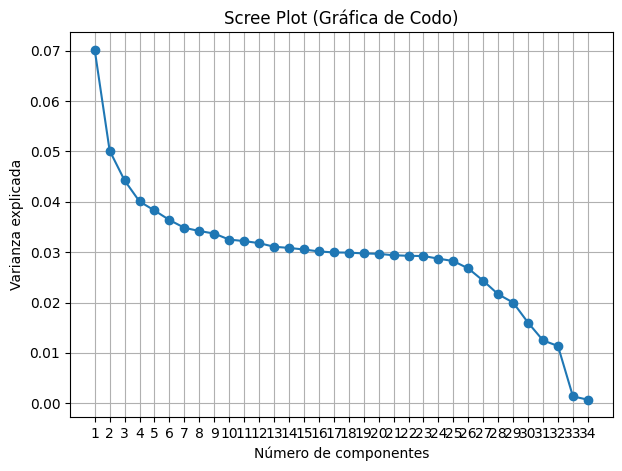

Varianza por componente: [0.07021597 0.05018201 0.04425383 0.04006965 0.03828584 0.03639074
 0.03484329 0.03420672 0.03369722 0.03250275 0.03220373 0.03179833
 0.03108438 0.03084494 0.03053296 0.0301533  0.02994998 0.02991254
 0.0297554  0.02967613 0.02938492 0.02928273 0.02923136 0.0287146
 0.02823196 0.02676725 0.02432046 0.02163146 0.01999497 0.01599043
 0.01247732 0.01135878 0.00136229 0.00069174]
Varianza acumulada: [0.07021597 0.12039798 0.16465181 0.20472146 0.24300729 0.27939803
 0.31424133 0.34844805 0.38214527 0.41464802 0.44685175 0.47865008
 0.50973446 0.5405794  0.57111237 0.60126567 0.63121565 0.66112819
 0.69088359 0.72055972 0.74994464 0.77922737 0.80845873 0.83717333
 0.8654053  0.89217255 0.91649301 0.93812446 0.95811944 0.97410987
 0.98658719 0.99794597 0.99930826 1.        ]


In [8]:

pca_full = PCA()
pca_full.fit(X_scaled_imputed)
plt.figure(figsize=(7,5))
plt.plot(
range(1, len(pca_full.explained_variance_ratio_) + 1),
pca_full.explained_variance_ratio_,
marker='o'
)
plt.xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada")
plt.title("Scree Plot (Gráfica de Codo)")
plt.grid(True)
plt.show()
print("Varianza por componente:", pca_full.explained_variance_ratio_)
print("Varianza acumulada:", pca_full.explained_variance_ratio_.cumsum())

Gráfico Biplot

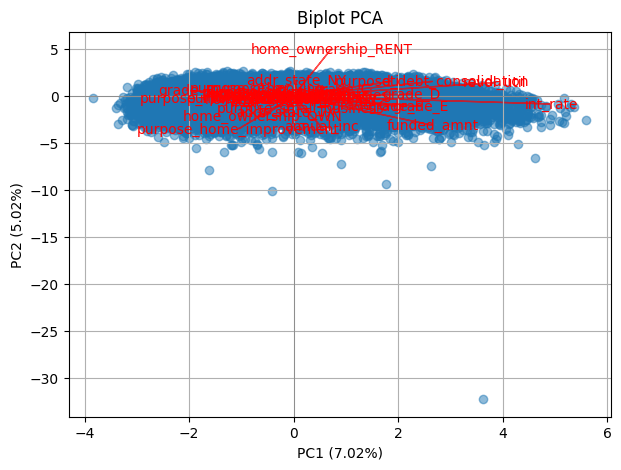

In [9]:
pca = PCA(n_components=6) # Definimos el PCA con 6 componentes
components = pca.fit_transform(X_scaled_imputed) # Calcular el PCA
# Componentes
PC1 = components[:, 0]
PC2 = components[:, 1]
PC3 = components[:, 2]
PC4 = components[:, 3]
PC5 = components[:, 4]
PC6 = components[:, 5]
loadings = pca.components_.T # loadings (vectores)
variables = X_encoded.columns # Guarda los nombres de las variables originales, que ahora son las columnas de X_encoded
plt.figure(figsize=(7,5))
# Graficar puntos (scores)
plt.scatter(PC1, PC2, alpha=0.5)
# Etiquetas de ejes
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")

# Graficar vectores (loadings)
for i, var in enumerate(variables):
  plt.arrow(0, 0,
            loadings[i,0]*9, # multiplicador para mejorar visualización
            loadings[i,1]*9,
            color='red',
            alpha=0.7,
            head_width=0.05)
  plt.text(loadings[i,0]*9.2,
           loadings[i,1]*9.2,
            var, color='red', ha='center', va='center')

plt.title("Biplot PCA")
plt.grid(True)
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.show()

Mejorar Apariencia

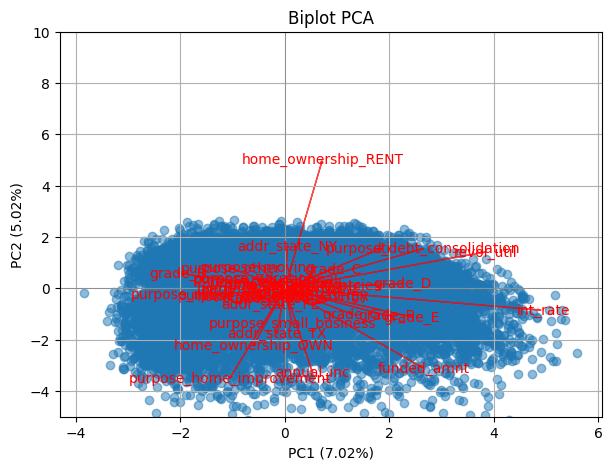

In [10]:
pca = PCA(n_components=6) # Definimos el PCA con 6 componentes
components = pca.fit_transform(X_scaled_imputed) # Calcular el PCA
# Componentes
PC1 = components[:, 0]
PC2 = components[:, 1]
PC3 = components[:, 2]
PC4 = components[:, 3]
PC5 = components[:, 4]
PC6 = components[:, 5]
loadings = pca.components_.T # loadings (vectores)
variables = X_encoded.columns # Guarda los nombres de las variables originales, que ahora son las columnas de X_encoded
plt.figure(figsize=(7,5))
# Graficar puntos (scores)
plt.scatter(PC1, PC2, alpha=0.5)

# Etiquetas de ejes
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.ylim(-5, 10) # Ajustar
# Graficar vectores (loadings)
for i, var in enumerate(variables):
  plt.arrow(0, 0,
            loadings[i,0]*9, # multiplicador para mejorar visualización
            loadings[i,1]*9,
            color='red',
            alpha=0.7,
            head_width=0.05)

  plt.text(loadings[i,0]*9.2,
           loadings[i,1]*9.2,
           var, color='red', ha='center', va='center')

plt.title("Biplot PCA")
plt.grid(True)
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.show()

Biplot de componentes PC3 y PC4

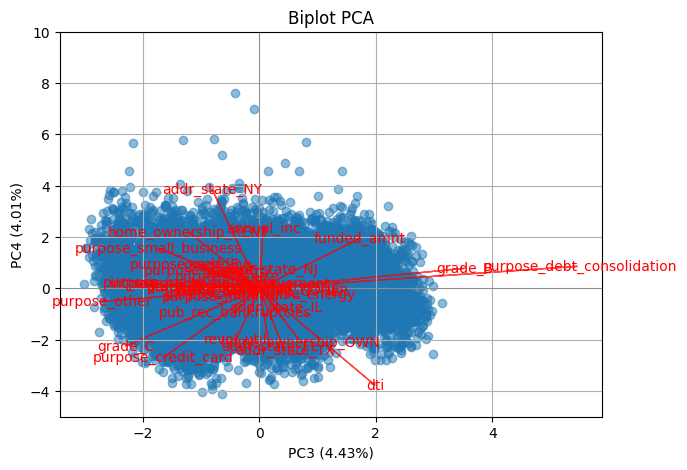

In [11]:
pca = PCA(n_components=6) # Definimos el PCA con 6 componentes
components = pca.fit_transform(X_scaled_imputed) # Calcular el PCA
# Componentes
PC1 = components[:, 0]
PC2 = components[:, 1]
PC3 = components[:, 2]
PC4 = components[:, 3]
PC5 = components[:, 4]
PC6 = components[:, 5]
loadings = pca.components_.T # loadings (vectores)
variables = X_encoded.columns # Guarda los nombres de las variables originales, que ahora son las columnas de X_encoded
plt.figure(figsize=(7,5))
# Graficar puntos (scores)
plt.scatter(PC3, PC4, alpha=0.5 )

# Etiquetas de ejes
plt.xlabel(f"PC3 ({pca.explained_variance_ratio_[2]*100:.2f}%)")
plt.ylabel(f"PC4 ({pca.explained_variance_ratio_[3]*100:.2f}%)")
plt.ylim(-5, 10) # Ajustar
# Graficar vectores (loadings)
for i, var in enumerate(variables):
  plt.arrow(0, 0,
            loadings[i,2]*9, # multiplicador para mejorar visualización
            loadings[i,3]*9,
            color='red',
            alpha=0.7,
            head_width=0.05)

  plt.text(loadings[i,2]*9.2,
           loadings[i,3]*9.2,
           var, color='red', ha='center', va='center')


plt.title("Biplot PCA")
plt.grid(True)
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.show()